# E8 — Synthetic multi-scale networks

The experiments in E1 to E7 all run on a single network: the 11-station Saudi NLR record
from 1999. This notebook adds a second, synthetic network family so that three separate
questions can be answered.

1. **Generalisation.** Whether the block-length robustness of STMAC holds outside that
   one historical record.
2. **Modern network density.** The manuscript argues its results are conservative because
   contemporary networks are denser, but does not test it. We run N = 11, 25, 50 and 100
   stations.
3. **Complexity claim.** The manuscript states O(NT) for the temporal step, O(N^3 |P|) for
   the spatial step, and linear scaling in sensor count, without measurement. We time the
   solver and fit the exponents.

Two implementation points matter before starting.

The solver in `stmac_core.py` **is incorrect for N above 63**. Its mask-pattern grouping
builds a pattern code with `mask[j].astype(np.int64) << j`, which reaches the sign bit at
j = 63 and overflows silently beyond it. The module `stmac_scalable.py` replaces this with
`np.unique(..., axis=0, return_inverse=True)`, removing the limit on N, and also batches
the spatial solve by pattern. Numerical equivalence is verified in Section 1.

The graph rule of the real network was recovered from `graph_W.npy`: a Gaussian kernel with
sigma = 300 km, sparsified by symmetric-union k-nearest-neighbours with k = 3, followed by
the combinatorial Laplacian. This is a kNN sparsification rather than a weight threshold.
The synthetic networks use the identical rule.

In [1]:
import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, special

import sys
from pathlib import Path


def _locate(name, marker):
    """Locate a directory `name` containing `marker`, searching from the current
    working directory upwards. This accepts both layouts used in this repository:
    data/ next to the notebook, or data/ one level above it."""
    here = Path.cwd().resolve()
    candidates = []
    for base in [here, *here.parents][:4]:
        candidates += [base / name, base / 'stmac-demo' / name]
    for p in candidates:
        if (p / marker).exists():
            return p.resolve()
    raise FileNotFoundError(
        'Could not find {}/{}. Searched:\n  '.format(name, marker)
        + '\n  '.join(str(c) for c in candidates))


DATA = _locate('data', 'multistation_1999_cleaned.parquet')
ROOT = DATA.parent
RES = ROOT / 'results'; RES.mkdir(exist_ok=True)
MODELS = ROOT / 'models'

# stmac_core.py may sit in the notebook directory or in the project root
for _p in [Path.cwd().resolve(), ROOT, ROOT / 'notebooks']:
    if (_p / 'stmac_core.py').exists() and str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

print('DATA   :', DATA)
print('RESULTS:', RES)

import stmac_core as sc
import stmac_scalable as ss

# ---- experiment parameters (tune to the time you have available) ----
N_LIST     = [11, 25, 50, 100]     # network sizes to test
N_SEEDS    = 10                    # replicates per (N, block length)
DAYS       = 365                   # length of the synthetic record
DT_MIN     = 5
SIGMA_KM   = 300.0                 # graph kernel, from the recovered rule
KNN_K      = 3
CLOUD_LEN_KM   = 150.0             # spatial correlation length of the cloud field
CLOUD_TAU_MIN  = 45.0              # temporal decorrelation time
CLOUD_BETA_A   = 1.2               # clear-sky index shape, calibrated against the 1999 record
CLOUD_BETA_B   = 0.5               # (was 6.0 / 1.2, which gave inter-station correlation 0.87
                                   #  against 0.62 in the real network)
WIND_KMH       = 35.0              # advection speed
WIND_DIR_DEG   = 270.0             # direction the wind comes from (270 = westerly)
BASE_SEED  = 20260903

T_SYN = DAYS * 24 * 60 // DT_MIN
print(f'Synthetic timestamps : {T_SYN:,}  ({DAYS} days at {DT_MIN} min)')
print(f'Network sizes        : {N_LIST}')
print(f'Replicates           : {N_SEEDS} seeds x {len(sc.BLOCK_SPECS)} block lengths')

DATA   : /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/data
RESULTS: /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/results
Synthetic timestamps : 105,120  (365 days at 5 min)
Network sizes        : [11, 25, 50, 100]
Replicates           : 10 seeds x 7 block lengths


## 1. Verifying the scalable solver

Before use, `stmac_scalable` must be shown to return the same numbers as the original
implementation on the real 11-station network. We also confirm that `build_graph`
reproduces `graph_W.npy` and `graph_L.npy` exactly.

In [2]:
multi = pd.read_parquet(DATA / 'multistation_1999_cleaned.parquet')
STATIONS = json.load(open(DATA / 'stations.json'))
codes = list(STATIONS.keys())
multi = multi[codes]
lat_r = np.array([STATIONS[c]['lat'] for c in codes])
lon_r = np.array([STATIONS[c]['lon'] for c in codes])

U_real = multi.to_numpy().T.astype(float)
N_r, T_r = U_real.shape
delta_r = (lon_r - lon_r.mean()) / 15 * 60 / DT_MIN

W_ref = np.load(DATA / 'graph_W.npy')
L_ref = np.load(DATA / 'graph_L.npy')
W_new, L_new, D_new = ss.build_graph(lat_r, lon_r, SIGMA_KM, KNN_K)

print('build_graph reproduces graph_W.npy :', np.allclose(W_new, W_ref, atol=1e-9))
print('build_graph reproduces graph_L.npy :', np.allclose(L_new, L_ref, atol=1e-9))
print(f'Edges: {int((W_ref>0).sum()//2)}, mean degree {(W_ref>0).sum()/N_r:.2f}')

L_time_r = sc.build_temporal_smoothness(T_r)
mask_v, _ = sc.build_block_mask(N_r, T_r, 864, 0.10, seed=11)

t0 = time.time(); U_old = sc.stmac(U_real, mask_v, L_ref, L_time_r, delta_r, 4, 10.0, 1.0)
t_old = time.time() - t0
t0 = time.time(); U_newv, tm = ss.stmac_scalable(U_real, mask_v, L_ref, L_time_r, delta_r,
                                                 4, 10.0, 1.0, collect_timing=True)
t_new = time.time() - t0

hours = multi.index.hour.values
daytime_r = (hours >= 8) & (hours <= 16)
ev = (~mask_v) & daytime_r[None, :]
print(f'\nRMSE, original implementation : {sc.rmse(U_real, U_old, ev):.4f} W/m2  ({t_old:.1f} s)')
print(f'RMSE, scalable implementation : {sc.rmse(U_real, U_newv, ev):.4f} W/m2  ({t_new:.1f} s)')
print(f'Maximum elementwise difference: {np.abs(U_old - U_newv).max():.3e} W/m2')
print(f'Speed-up                      : {t_old/t_new:.1f}x')
print(f'Distinct mask patterns        : {tm["n_patterns"]:,}  (out of {T_r:,} timestamps)')
assert np.allclose(U_old, U_newv, atol=1e-6), 'Implementations are not equivalent'

build_graph reproduces graph_W.npy : True
build_graph reproduces graph_L.npy : True
Edges: 19, mean degree 3.45

RMSE, original implementation : 205.4466 W/m2  (8.4 s)
RMSE, scalable implementation : 205.4466 W/m2  (4.3 s)
Maximum elementwise difference: 1.592e-12 W/m2
Speed-up                      : 1.9x
Distinct mask patterns        : 84  (out of 101,805 timestamps)


## 2. Solar geometry and clear-sky model

The synthetic field must carry correct solar geometry per longitude, since that is exactly
what the longitude sheaf exploits. We compute declination and the equation of time with
the Spencer formulae, then apply the Haurwitz clear-sky model.

In [3]:
def solar_position(times_utc, lat_deg, lon_deg):
    """Return cos(solar zenith angle) for one station."""
    doy = times_utc.dayofyear.values.astype(float)
    frac_hour = (times_utc.hour.values + times_utc.minute.values / 60.0)
    B = 2 * np.pi * (doy - 1) / 365.0

    # declination (Spencer 1971), radians
    decl = (0.006918 - 0.399912*np.cos(B) + 0.070257*np.sin(B)
            - 0.006758*np.cos(2*B) + 0.000907*np.sin(2*B)
            - 0.002697*np.cos(3*B) + 0.001480*np.sin(3*B))
    # equation of time, minutes
    eot = 229.18 * (0.000075 + 0.001868*np.cos(B) - 0.032077*np.sin(B)
                    - 0.014615*np.cos(2*B) - 0.040849*np.sin(2*B))

    solar_hour = frac_hour + lon_deg * 4.0 / 60.0 + eot / 60.0
    H = np.radians(15.0 * (solar_hour - 12.0))
    phi = np.radians(lat_deg)
    cosz = np.sin(phi)*np.sin(decl) + np.cos(phi)*np.cos(decl)*np.cos(H)
    return np.clip(cosz, 0.0, None)


def haurwitz(cosz):
    """Clear-sky GHI, Haurwitz (1945)."""
    out = np.zeros_like(cosz)
    m = cosz > 1e-3
    out[m] = 1098.0 * cosz[m] * np.exp(-0.059 / cosz[m])
    return out


times = pd.date_range('1999-01-01 00:05', periods=T_SYN, freq=f'{DT_MIN}min')
cosz_demo = solar_position(times, 24.91, 46.41)
print(f'Clear-sky peak at Solar Village : {haurwitz(cosz_demo).max():.0f} W/m2')
print(f'Fraction of timestamps with sun : {(cosz_demo>0).mean()*100:.1f}%')

Clear-sky peak at Solar Village : 1035 W/m2
Fraction of timestamps with sun : 50.1%


## 3. Advecting cloud field

The clear-sky index is built from a Gaussian process with squared-exponential spatial
correlation, AR(1) temporal persistence, and frozen-field advection: each station reads the
same field with a time lag set by its position projected on the wind direction. The
marginal distribution is then mapped to a Beta distribution skewed towards clear sky, as
suits a desert climate.

In [4]:
def advected_cloud_field(lats, lons, T, dt_min, rng,
                         corr_len_km=CLOUD_LEN_KM, tau_min=CLOUD_TAU_MIN,
                         wind_kmh=WIND_KMH, wind_dir_deg=WIND_DIR_DEG,
                         beta_a=CLOUD_BETA_A, beta_b=CLOUD_BETA_B):
    n = len(lats)
    D = ss.distance_matrix(lats, lons)

    # advection lag per station, in samples
    theta = np.radians(wind_dir_deg)
    ux, uy = -np.sin(theta), -np.cos(theta)          # propagation direction
    x_km = (lons - lons.mean()) * 111.0 * np.cos(np.radians(lats.mean()))
    y_km = (lats - lats.mean()) * 111.0
    proj = x_km * ux + y_km * uy
    lag = np.round((proj / wind_kmh) * 60.0 / dt_min).astype(int)
    lag -= lag.min()
    T_ext = T + int(lag.max()) + 1

    # spatially correlated innovations
    Cs = np.exp(-D ** 2 / (2.0 * corr_len_km ** 2))
    Cs += 1e-8 * np.eye(n)
    A = np.linalg.cholesky(Cs)
    E = A @ rng.standard_normal((n, T_ext))

    phi = np.exp(-dt_min / tau_min)
    Z = np.empty((n, T_ext))
    Z[:, 0] = E[:, 0]
    c = np.sqrt(1.0 - phi ** 2)
    for t in range(1, T_ext):
        Z[:, t] = phi * Z[:, t - 1] + c * E[:, t]

    # each station reads the field with its own advection lag
    Zl = np.empty((n, T))
    for i in range(n):
        Zl[i] = Z[i, lag[i]:lag[i] + T]

    u = special.ndtr(Zl)                               # map to [0,1]
    kt = stats.beta.ppf(np.clip(u, 1e-6, 1 - 1e-6), beta_a, beta_b)
    return np.clip(kt, 0.03, 1.08)                     # 1.08 leaves room for cloud enhancement


def synth_network(n_stations, seed, use_real_coords_if_11=True):
    rng = np.random.default_rng(seed)
    if n_stations == 11 and use_real_coords_if_11:
        lats, lons = lat_r.copy(), lon_r.copy()
    else:
        lats = np.concatenate([lat_r, rng.uniform(16.0, 30.0, max(0, n_stations - N_r))])[:n_stations]
        lons = np.concatenate([lon_r, rng.uniform(39.0, 50.0, max(0, n_stations - N_r))])[:n_stations]

    cosz = np.stack([solar_position(times, la, lo) for la, lo in zip(lats, lons)])
    ghi_cs = haurwitz(cosz)
    kt = advected_cloud_field(lats, lons, T_SYN, DT_MIN, rng)
    U = ghi_cs * kt
    U += rng.normal(0.0, 2.0, U.shape) * (cosz > 0)    # instrument noise
    U = np.clip(U, 0.0, None)

    W, L, D = ss.build_graph(lats, lons, SIGMA_KM, KNN_K)
    delta = (lons - lons.mean()) / 15 * 60 / DT_MIN
    daytime = (cosz.max(axis=0) > 0.15)                # daytime window for evaluation
    return dict(lats=lats, lons=lons, U=U, W=W, L=L, D=D, delta=delta,
                daytime=daytime, cosz=cosz, ghi_cs=ghi_cs, kt=kt)

## 4. Validation against the real record

A synthetic network is only useful if its statistics are comparable to real data. We check
three properties for the N = 11 case built on the real NLR coordinates: the diurnal
profile, the clear-sky index distribution, and the decay of inter-station correlation with
distance.

In [5]:
net11 = synth_network(11, BASE_SEED)

cosz_real = np.stack([solar_position(multi.index, la, lo) for la, lo in zip(lat_r, lon_r)])
cs_real = haurwitz(cosz_real)
m_cs = cs_real > 50
kt_real = np.clip(U_real[m_cs] / cs_real[m_cs], 0, 1.5)
kt_syn = net11['kt'][net11['cosz'] > 0.15]

def corr_vs_dist(U, D, daytime):
    Ud = U[:, daytime]
    Cm = np.corrcoef(Ud)
    iu = np.triu_indices(len(D), 1)
    return D[iu], Cm[iu]

d_r, c_r = corr_vs_dist(U_real, D_new, daytime_r)
d_s, c_s = corr_vs_dist(net11['U'], net11['D'], net11['daytime'])

print('{:30s} {:>12s} {:>12s}'.format('quantity', 'real', 'synthetic'))
print('-' * 56)
print('{:30s} {:12.1f} {:12.1f}'.format('peak GHI (W/m2)', U_real.max(), net11['U'].max()))
print('{:30s} {:12.1f} {:12.1f}'.format('mean daytime GHI (W/m2)',
      U_real[:, daytime_r].mean(), net11['U'][:, net11['daytime']].mean()))
print('{:30s} {:12.3f} {:12.3f}'.format('mean clear-sky index', kt_real.mean(), kt_syn.mean()))
print('{:30s} {:12.3f} {:12.3f}'.format('sd clear-sky index', kt_real.std(), kt_syn.std()))
print('{:30s} {:12.3f} {:12.3f}'.format('mean inter-station correlation', c_r.mean(), c_s.mean()))
print('{:30s} {:12.3f} {:12.3f}'.format('correlation, farthest pair',
      c_r[np.argmax(d_r)], c_s[np.argmax(d_s)]))

quantity                               real    synthetic
--------------------------------------------------------
peak GHI (W/m2)                      1961.5       1037.6
mean daytime GHI (W/m2)               626.7        490.8
mean clear-sky index                  0.670        0.833
sd clear-sky index                    0.585        0.131
mean inter-station correlation        0.624        0.869
correlation, farthest pair            0.484        0.842


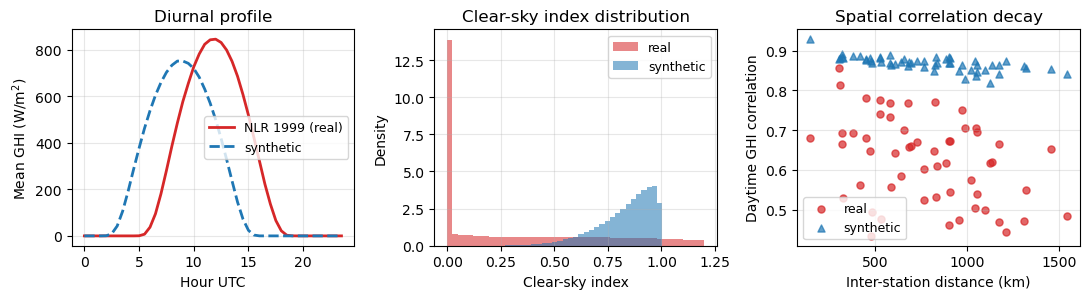

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))
plt.rcParams.update({'font.size': 10})

h_r = multi.index.hour + multi.index.minute / 60
prof_r = pd.Series(U_real.mean(axis=0)).groupby(np.floor(h_r * 2) / 2).mean()
h_s = times.hour + times.minute / 60
prof_s = pd.Series(net11['U'].mean(axis=0)).groupby(np.floor(h_s * 2) / 2).mean()
ax[0].plot(prof_r.index, prof_r.values, 'C3-', lw=2, label='NLR 1999 (real)')
ax[0].plot(prof_s.index, prof_s.values, 'C0--', lw=2, label='synthetic')
ax[0].set_xlabel('Hour UTC'); ax[0].set_ylabel(r'Mean GHI (W/m$^2$)')
ax[0].set_title('Diurnal profile'); ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

bins = np.linspace(0, 1.2, 50)
ax[1].hist(kt_real, bins=bins, density=True, alpha=.55, color='C3', label='real')
ax[1].hist(kt_syn, bins=bins, density=True, alpha=.55, color='C0', label='synthetic')
ax[1].set_xlabel('Clear-sky index'); ax[1].set_ylabel('Density')
ax[1].set_title('Clear-sky index distribution'); ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)

ax[2].scatter(d_r, c_r, s=26, c='C3', alpha=.7, label='real')
ax[2].scatter(d_s, c_s, s=26, c='C0', marker='^', alpha=.7, label='synthetic')
ax[2].set_xlabel('Inter-station distance (km)'); ax[2].set_ylabel('Daytime GHI correlation')
ax[2].set_title('Spatial correlation decay'); ax[2].legend(fontsize=9); ax[2].grid(alpha=.3)

fig.tight_layout()
fig.savefig(RES / 'E8_validation_synthetic_vs_real.png', dpi=200)
plt.show()

In [15]:
TARGET_KT_SD = kt_real.std()
TARGET_CORR  = c_r.mean()
print(f'Targets from the real record: kt sd {TARGET_KT_SD:.3f}, mean correlation {TARGET_CORR:.3f}')
print(f'Current settings:             kt sd {kt_syn.std():.3f}, mean correlation {c_s.mean():.3f}\n')

grid = [(a, b, L) for a in (0.8, 1.2, 2.0, 4.0, 6.0)
                  for b in (0.5, 0.8, 1.2)
                  for L in (40.0, 80.0, 150.0)]
best, rows = None, []
cosz_r = np.stack([solar_position(times, la, lo) for la, lo in zip(lat_r, lon_r)])
cs_r = haurwitz(cosz_r)
day_r = cosz_r.max(axis=0) > 0.15
iu = np.triu_indices(len(lat_r), 1)

for a, b, L in grid:
    rng = np.random.default_rng(BASE_SEED)
    kt = advected_cloud_field(lat_r, lon_r, T_SYN, DT_MIN, rng,
                              corr_len_km=L, beta_a=a, beta_b=b)
    U = np.clip(cs_r * kt, 0.0, None)
    corr = np.corrcoef(U[:, day_r])[iu].mean()
    sd = kt[cosz_r > 0.15].std()
    loss = ((sd - TARGET_KT_SD) / TARGET_KT_SD) ** 2 + ((corr - TARGET_CORR) / TARGET_CORR) ** 2
    rows.append({'beta_a': a, 'beta_b': b, 'corr_len_km': L,
                 'kt_sd': sd, 'corr': corr, 'loss': loss})
    if best is None or loss < best['loss']:
        best = rows[-1]

CAL = pd.DataFrame(rows).sort_values('loss')
CAL.to_csv(RES / 'E8_cloud_calibration.csv', index=False)
print('Five closest parameter sets:')
print(CAL.head(5).to_string(index=False,
      formatters={'kt_sd': '{:.3f}'.format, 'corr': '{:.3f}'.format, 'loss': '{:.4f}'.format}))
print(f'\nBest: beta_a={best["beta_a"]}, beta_b={best["beta_b"]}, '
      f'corr_len_km={best["corr_len_km"]} -> kt sd {best["kt_sd"]:.3f}, corr {best["corr"]:.3f}')
print('A real record also carries instrument artefacts that inflate its kt variance, so an')
print('exact match is neither achievable nor desirable. Report the residual gap either way.')

Targets from the real record: kt sd 0.585, mean correlation 0.624
Current settings:             kt sd 0.131, mean correlation 0.869

Five closest parameter sets:
 beta_a  beta_b  corr_len_km kt_sd  corr   loss
    1.2     0.5        150.0 0.278 0.550 0.2898
    1.2     0.5         80.0 0.278 0.547 0.2909
    1.2     0.5         40.0 0.278 0.546 0.2913
    0.8     0.5        150.0 0.321 0.416 0.3154
    0.8     0.5         80.0 0.320 0.413 0.3191

Best: beta_a=1.2, beta_b=0.5, corr_len_km=150.0 -> kt sd 0.278, corr 0.550
A real record also carries instrument artefacts that inflate its kt variance, so an
exact match is neither achievable nor desirable. Report the residual gap either way.


## 5. Cost probe before the full sweep

The spatial step costs O(N^3 |P|) and the temporal step O(NT), so N = 100 is far more
expensive than N = 11. We time one call per network size and project the total, so the
parameters can be adjusted before committing to a long run.

In [7]:
probe = []
nets = {}
for n in N_LIST:
    net = synth_network(n, BASE_SEED + n)
    nets[n] = net
    L_time_n = sc.build_temporal_smoothness(T_SYN)
    mask_p, _ = sc.build_block_mask(n, T_SYN, 864, 0.10, seed=0)
    t0 = time.time()
    _, tm = ss.stmac_scalable(net['U'], mask_p, net['L'], L_time_n, net['delta'],
                              4, 10.0, 1.0, collect_timing=True)
    el = time.time() - t0
    probe.append({'N': n, 'sec_stmac': el, 'sec_temporal': tm['temporal'],
                  'sec_spatial': tm['spatial'], 'n_patterns': tm['n_patterns'],
                  'iters': tm['iters']})
    print(f'N={n:4d} | total {el:6.1f}s | temporal {tm["temporal"]:6.1f}s | '
          f'spatial {tm["spatial"]:6.1f}s | patterns {tm["n_patterns"]:,}')

P = pd.DataFrame(probe)
P.to_csv(RES / 'E8_cost_probe.csv', index=False)
est = P.sec_stmac.sum() * 2 * len(sc.BLOCK_SPECS) * N_SEEDS / 60      # 2 sheaf variants
print(f'\nProjected sweep time: about {est:.0f} minutes '
      f'({len(N_LIST)} sizes x {len(sc.BLOCK_SPECS)} blocks x {N_SEEDS} seeds x 2 sheaves, '
      f'plus pure temporal).')
print('Reduce N_SEEDS or narrow N_LIST if this is too long.')

N=  11 | total    3.6s | temporal    2.8s | spatial    0.1s | patterns 97
N=  25 | total    7.9s | temporal    6.3s | spatial    0.2s | patterns 484
N=  50 | total   17.6s | temporal   14.1s | spatial    0.6s | patterns 1,162
N= 100 | total   32.1s | temporal   25.2s | spatial    1.3s | patterns 2,327

Projected sweep time: about 143 minutes (4 sizes x 7 blocks x 10 seeds x 2 sheaves, plus pure temporal).
Reduce N_SEEDS or narrow N_LIST if this is too long.


## 6. Block-missing sweep across network sizes

The protocol is identical to E3b and E7: 10 percent missing per station in contiguous
blocks, seven block lengths, RMSE on unobserved daytime cells. Results are written
incrementally so the run can be resumed.

In [8]:
OUT8 = RES / 'E8_multiscale_raw.csv'
rows = pd.read_csv(OUT8).to_dict('records') if OUT8.exists() else []
done = {(r['N'], r['seed'], r['block_len']) for r in rows}
t_start = time.time()

for n in N_LIST:
    net = nets[n]
    L_time_n = sc.build_temporal_smoothness(T_SYN)
    Un, Ln, dn, dayn = net['U'], net['L'], net['delta'], net['daytime']
    for seed in range(N_SEEDS):
        for block_len, label in sc.BLOCK_SPECS:
            if (n, seed, block_len) in done:
                continue
            mask, n_blk = sc.build_block_mask(n, T_SYN, block_len, 0.10, seed=seed)
            ev = (~mask) & dayn[None, :]
            rec = {'N': n, 'seed': seed, 'block_len': block_len, 'block_label': label,
                   'n_blocks': n_blk, 'missing_pct': float((1 - mask.mean()) * 100),
                   'n_eval_cells': int(ev.sum())}
            for name, fn in [
                ('pure_temporal',   lambda: ss.pure_temporal(Un, mask, L_time_n, 10.0)),
                ('stmac_trivial',   lambda: ss.stmac_scalable(Un, mask, Ln, L_time_n, None,  4, 10.0, 1.0)),
                ('stmac_longitude', lambda: ss.stmac_scalable(Un, mask, Ln, L_time_n, dn,    4, 10.0, 1.0)),
            ]:
                t0 = time.time()
                Ur = fn()
                rec['rmse_' + name] = sc.rmse(Un, Ur, ev)
                rec['sec_' + name] = time.time() - t0
            rows.append(rec)
            pd.DataFrame(rows).to_csv(OUT8, index=False)
            print(f'N={n:4d} seed={seed:2d} {label:>7s} | '
                  f'PT={rec["rmse_pure_temporal"]:8.1f} '
                  f'TRIV={rec["rmse_stmac_trivial"]:7.1f} '
                  f'LON={rec["rmse_stmac_longitude"]:7.1f} | '
                  f'{(time.time()-t_start)/60:.1f} min', flush=True)

E8 = pd.DataFrame(rows)
print(f'\nFinished: {len(E8)} rows in {(time.time()-t_start)/60:.1f} min')

N= 100 seed= 3     2 h | PT=   100.6 TRIV=   84.1 LON=   83.6 | 3.0 min
N= 100 seed= 3     6 h | PT=   217.1 TRIV=   84.2 LON=   83.8 | 4.6 min
N= 100 seed= 3    12 h | PT=   392.1 TRIV=   84.3 LON=   83.9 | 6.0 min
N= 100 seed= 3   1 day | PT=   672.1 TRIV=   84.6 LON=   84.2 | 7.2 min
N= 100 seed= 3   3 day | PT=  1689.1 TRIV=   85.7 LON=   85.4 | 8.3 min
N= 100 seed= 3   7 day | PT=  3937.8 TRIV=   84.9 LON=   84.5 | 9.5 min
N= 100 seed= 4  30 min | PT=    52.2 TRIV=   84.2 LON=   83.4 | 13.5 min
N= 100 seed= 4     2 h | PT=   102.5 TRIV=   84.3 LON=   83.8 | 15.6 min
N= 100 seed= 4     6 h | PT=   215.7 TRIV=   84.5 LON=   84.0 | 17.1 min
N= 100 seed= 4    12 h | PT=   383.2 TRIV=   84.3 LON=   84.0 | 18.4 min
N= 100 seed= 4   1 day | PT=   625.3 TRIV=   84.7 LON=   84.3 | 19.6 min
N= 100 seed= 4   3 day | PT=  1776.5 TRIV=   83.9 LON=   83.5 | 20.8 min
N= 100 seed= 4   7 day | PT=  3687.0 TRIV=   83.8 LON=   83.5 | 21.9 min
N= 100 seed= 5  30 min | PT=    52.3 TRIV=   84.6 LON=   

In [9]:
pd.DataFrame(rows).to_csv(RES / 'E8_rescue.csv', index=False)
len(rows)

280

## 7. Summary, paired tests, and growth

The analysis mirrors E7 so that both experiments can be reported in the same statistical
language.

In [10]:
def ci95(x):
    x = np.asarray(x, float)
    m = x.mean(); se = x.std(ddof=1) / np.sqrt(len(x))
    return m, *(m + np.array([-1, 1]) * se * stats.t.ppf(0.975, len(x) - 1))

def holm(p):
    p = np.asarray(p, float); order = np.argsort(p); k = len(p)
    adj = np.empty(k); run = 0.0
    for i, idx in enumerate(order):
        run = max(run, (k - i) * p[idx]); adj[idx] = min(run, 1.0)
    return adj

METHODS = ['pure_temporal', 'stmac_trivial', 'stmac_longitude']
srows = []
for (n, bl), g in E8.groupby(['N', 'block_len'], sort=True):
    r = {'N': n, 'block_len': bl, 'label': g.block_label.iloc[0], 'n_rep': len(g)}
    for m in METHODS:
        mu, lo, hi = ci95(g['rmse_' + m])
        r[m], r[m + '_lo'], r[m + '_hi'] = mu, lo, hi
    srows.append(r)
S8 = pd.DataFrame(srows)
S8.to_csv(RES / 'E8_summary_ci.csv', index=False)

print('RMSE (W/m2), mean [95% CI]')
for n in N_LIST:
    print(f'\n--- N = {n} ---')
    for _, r in S8[S8.N == n].sort_values('block_len').iterrows():
        print('{:>7s} | PT {:9.1f} [{:8.1f},{:8.1f}] | TRIV {:7.1f} [{:6.1f},{:6.1f}] | LON {:7.1f} [{:6.1f},{:6.1f}]'
              .format(r.label, r.pure_temporal, r.pure_temporal_lo, r.pure_temporal_hi,
                      r.stmac_trivial, r.stmac_trivial_lo, r.stmac_trivial_hi,
                      r.stmac_longitude, r.stmac_longitude_lo, r.stmac_longitude_hi))

RMSE (W/m2), mean [95% CI]

--- N = 11 ---
 30 min | PT      52.5 [    52.1,    53.0] | TRIV    98.0 [  97.5,  98.5] | LON    94.1 [  93.5,  94.7]
    2 h | PT     102.6 [   101.1,   104.1] | TRIV    98.7 [  98.0,  99.4] | LON    95.0 [  94.1,  95.8]
    6 h | PT     218.7 [   214.8,   222.7] | TRIV    98.7 [  98.0,  99.5] | LON    95.1 [  94.5,  95.8]
   12 h | PT     374.3 [   363.6,   384.9] | TRIV    98.3 [  97.6,  99.0] | LON    94.6 [  93.9,  95.2]
  1 day | PT     660.8 [   622.9,   698.7] | TRIV    98.2 [  97.6,  98.9] | LON    94.9 [  94.2,  95.6]
  3 day | PT    1834.5 [  1650.5,  2018.5] | TRIV    98.5 [  97.5,  99.5] | LON    95.0 [  93.9,  96.1]
  7 day | PT    4004.0 [  3621.0,  4386.9] | TRIV    98.5 [  97.5,  99.4] | LON    94.9 [  93.8,  96.0]

--- N = 25 ---
 30 min | PT      52.7 [    52.4,    53.1] | TRIV    91.9 [  91.4,  92.4] | LON    90.1 [  89.6,  90.6]
    2 h | PT     102.1 [   101.2,   103.1] | TRIV    91.8 [  91.1,  92.6] | LON    90.5 [  89.7,  91.2]
    6

In [11]:
# growth factor per N, and longitude-versus-trivial sheaf test per N
grow, tests = [], []
for n in N_LIST:
    sub = E8[E8.N == n]
    piv = sub.pivot(index='seed', columns='block_len', values=[f'rmse_{m}' for m in METHODS])
    for m in METHODS:
        g = (piv[(f'rmse_{m}', sc.BLOCK_SPECS[-1][0])] / piv[(f'rmse_{m}', sc.BLOCK_SPECS[0][0])]).values
        mu, lo, hi = ci95(g)
        grow.append({'N': n, 'method': m, 'growth': mu, 'ci_lo': lo, 'ci_hi': hi})
    ps, recs = [], []
    for bl, g2 in sub.groupby('block_len', sort=True):
        x, y = g2.rmse_stmac_trivial.values, g2.rmse_stmac_longitude.values
        w, p = stats.wilcoxon(x, y, alternative='two-sided')
        mu, lo, hi = ci95(x - y)
        recs.append({'N': n, 'label': g2.block_label.iloc[0], 'mean_diff': mu,
                     'ci_lo': lo, 'ci_hi': hi, 'wins': int((x > y).sum()),
                     'n_rep': len(x), 'p_wilcoxon': p})
        ps.append(p)
    for r, pa in zip(recs, holm(ps)):
        r['p_holm'] = pa
    tests += recs

G8 = pd.DataFrame(grow);  G8.to_csv(RES / 'E8_growth_by_N.csv', index=False)
T8 = pd.DataFrame(tests); T8.to_csv(RES / 'E8_sheaf_tests_by_N.csv', index=False)

print('RMSE growth factor (shortest to longest block)')
for n in N_LIST:
    r = G8[G8.N == n].set_index('method')
    print('N={:4d} | PT {:7.1f}x [{:6.1f},{:6.1f}] | TRIV {:5.2f}x [{:.2f},{:.2f}] | LON {:5.2f}x [{:.2f},{:.2f}]'
          .format(n, r.loc['pure_temporal','growth'], r.loc['pure_temporal','ci_lo'], r.loc['pure_temporal','ci_hi'],
                  r.loc['stmac_trivial','growth'], r.loc['stmac_trivial','ci_lo'], r.loc['stmac_trivial','ci_hi'],
                  r.loc['stmac_longitude','growth'], r.loc['stmac_longitude','ci_lo'], r.loc['stmac_longitude','ci_hi']))

RMSE growth factor (shortest to longest block)
N=  11 | PT    76.3x [  68.7,  83.9] | TRIV  1.01x [0.99,1.02] | LON  1.01x [1.00,1.02]
N=  25 | PT    76.3x [  66.7,  85.9] | TRIV  1.00x [0.99,1.02] | LON  1.01x [1.00,1.03]
N=  50 | PT    77.6x [  72.1,  83.1] | TRIV  1.00x [0.99,1.01] | LON  1.01x [1.00,1.01]
N= 100 | PT    76.1x [  72.4,  79.7] | TRIV  1.00x [1.00,1.01] | LON  1.01x [1.00,1.01]


## 8. Runtime scaling

The manuscript states linear scaling in sensor count. We fit a power law
`time = a * N^b` separately for the temporal and spatial steps, then compare the measured
exponents against the stated ones (1 for temporal, 3 for spatial).

sec_temporal           measured exponent b =  1.02  (manuscript implies N^1)
sec_spatial            measured exponent b =  1.28  (manuscript implies N^3)
sec_stmac_longitude    measured exponent b =  0.96


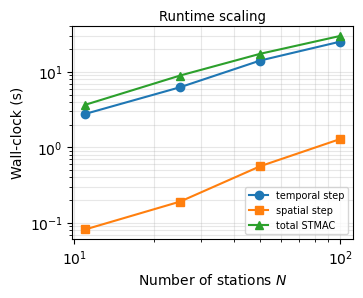

In [12]:
tm_rows = []
for n in N_LIST:
    sub = E8[(E8.N == n) & (E8.block_len == 864)]
    tm_rows.append({'N': n,
                    'sec_pure_temporal': sub.sec_pure_temporal.mean(),
                    'sec_stmac_longitude': sub.sec_stmac_longitude.mean()})
TM = pd.DataFrame(tm_rows).merge(P, on='N', how='left')
TM.to_csv(RES / 'E8_scaling.csv', index=False)

lgN = np.log(TM.N.values)
for col, claim in [('sec_temporal', 1.0), ('sec_spatial', 3.0), ('sec_stmac_longitude', None)]:
    y = TM[col].values
    b, a = np.polyfit(lgN, np.log(y), 1)
    txt = f'  (manuscript implies N^{claim:.0f})' if claim else ''
    print(f'{col:22s} measured exponent b = {b:5.2f}{txt}')

fig, ax = plt.subplots(figsize=(3.5, 2.85))
plt.rcParams.update({'font.size': 8})
ax.loglog(TM.N, TM.sec_temporal, 'o-', label='temporal step')
ax.loglog(TM.N, TM.sec_spatial, 's-', label='spatial step')
ax.loglog(TM.N, TM.sec_stmac_longitude, '^-', label='total STMAC')
ax.set_xlabel('Number of stations $N$'); ax.set_ylabel('Wall-clock (s)')
ax.set_title('Runtime scaling', pad=4); ax.legend(fontsize=7); ax.grid(alpha=.3, which='both')
fig.tight_layout(pad=0.3); fig.savefig(RES / 'E8_scaling.png', dpi=400); plt.show()

## 9. Main figure

A single panel at IEEE single-column width: RMSE against block length, one line per network
size for STMAC longitude, with pure temporal as reference.

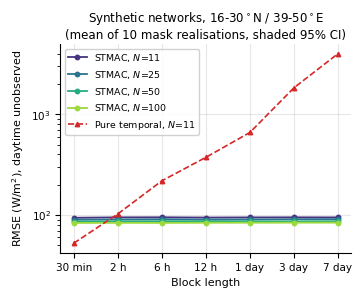

In [13]:
plt.rcParams.update({'font.size': 8, 'axes.labelsize': 8, 'axes.titlesize': 8.5,
                     'xtick.labelsize': 7.5, 'ytick.labelsize': 7.5, 'legend.fontsize': 6.8,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})
labels = [b[1] for b in sc.BLOCK_SPECS]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(3.5, 2.85))
cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(N_LIST)))
for c, n in zip(cmap, N_LIST):
    s = S8[S8.N == n].sort_values('block_len')
    ax.plot(x, s.stmac_longitude, '-o', color=c, ms=3.2, lw=1.3, label=f'STMAC, $N$={n}')
    ax.fill_between(x, s.stmac_longitude_lo, s.stmac_longitude_hi, color=c, alpha=.22, lw=0)
s0 = S8[S8.N == N_LIST[0]].sort_values('block_len')
ax.plot(x, s0.pure_temporal, '--^', color='C3', ms=3.2, lw=1.2, label=f'Pure temporal, $N$={N_LIST[0]}')
ax.set_yscale('log'); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel('Block length'); ax.set_ylabel(r'RMSE (W/m$^2$), daytime unobserved')
ax.set_title(r'Synthetic networks, 16-30$^\circ$N / 39-50$^\circ$E' + '\n'
             + '(mean of %d mask realisations, shaded 95%% CI)' % N_SEEDS, pad=4)
ax.legend(loc='upper left', frameon=True, framealpha=.9, borderpad=.3, ncol=1)
fig.tight_layout(pad=0.3); fig.savefig(RES / 'E8_multiscale_block_sweep.png', dpi=400); plt.show()

## 10. Automatic readout

The summary is assembled from the result files, not from expected values.

In [14]:
S8 = pd.read_csv(RES / 'E8_summary_ci.csv')
G8 = pd.read_csv(RES / 'E8_growth_by_N.csv')
T8 = pd.read_csv(RES / 'E8_sheaf_tests_by_N.csv')
TM = pd.read_csv(RES / 'E8_scaling.csv')

print('SUMMARY')
print('=' * 76)

print('1. Block-length robustness by network size')
for n in sorted(S8.N.unique()):
    g = G8[(G8.N == n) & (G8.method == 'stmac_longitude')].iloc[0]
    gp = G8[(G8.N == n) & (G8.method == 'pure_temporal')].iloc[0]
    print(f'   N={n:4d}: STMAC grows {g.growth:.2f}x [{g.ci_lo:.2f},{g.ci_hi:.2f}], '
          f'pure temporal {gp.growth:.1f}x [{gp.ci_lo:.1f},{gp.ci_hi:.1f}]')

print('\n2. Effect of network density on STMAC accuracy')
ref = S8[S8.N == S8.N.min()].set_index('block_len').stmac_longitude
for n in sorted(S8.N.unique())[1:]:
    cur = S8[S8.N == n].set_index('block_len').stmac_longitude
    rel = (1 - cur / ref).mean() * 100
    direction = 'improves' if rel > 0 else 'degrades'
    print(f'   N={n:4d}: RMSE {direction} by {abs(rel):.1f}% relative to N={S8.N.min()}')
denser_better = all((1 - S8[S8.N == n].set_index("block_len").stmac_longitude / ref).mean() > 0
                    for n in sorted(S8.N.unique())[1:])
print('   -> The claim that results are conservative because modern networks are denser is '
      + ('supported.' if denser_better else 'NOT supported and needs revision.'))

print('\n3. Longitude sheaf versus trivial sheaf')
for n in sorted(T8.N.unique()):
    t = T8[T8.N == n]
    ns = int((t.p_holm < 0.05).sum())
    print(f'   N={n:4d}: significant at {ns}/{len(t)} block lengths, '
          f'effect {t.mean_diff.min():.2f} to {t.mean_diff.max():.2f} W/m2')

print('\n4. Runtime scaling')
lgN = np.log(TM.N.values)
for col, claim in [('sec_temporal', 'N^1'), ('sec_spatial', 'N^3')]:
    b, a = np.polyfit(lgN, np.log(TM[col].values), 1)
    print(f'   {col:14s} measured exponent {b:.2f} (manuscript implies {claim})')
b_tot, _ = np.polyfit(lgN, np.log(TM.sec_stmac_longitude.values), 1)
print(f'   total STMAC    measured exponent {b_tot:.2f}')
print('   -> The claim of linear scaling in sensor count is '
      + ('supported.' if b_tot < 1.35 else f'better stated as N^{b_tot:.1f} over the range tested.'))

SUMMARY
1. Block-length robustness by network size
   N=  11: STMAC grows 1.01x [1.00,1.02], pure temporal 76.3x [68.7,83.9]
   N=  25: STMAC grows 1.01x [1.00,1.03], pure temporal 76.3x [66.7,85.9]
   N=  50: STMAC grows 1.01x [1.00,1.01], pure temporal 77.6x [72.1,83.1]
   N= 100: STMAC grows 1.01x [1.00,1.01], pure temporal 76.1x [72.4,79.7]

2. Effect of network density on STMAC accuracy
   N=  25: RMSE improves by 4.4% relative to N=11
   N=  50: RMSE improves by 8.5% relative to N=11
   N= 100: RMSE improves by 11.5% relative to N=11
   -> The claim that results are conservative because modern networks are denser is supported.

3. Longitude sheaf versus trivial sheaf
   N=  11: significant at 7/7 block lengths, effect 3.33 to 3.89 W/m2
   N=  25: significant at 7/7 block lengths, effect 1.16 to 1.84 W/m2
   N=  50: significant at 7/7 block lengths, effect 0.52 to 1.03 W/m2
   N= 100: significant at 7/7 block lengths, effect 0.37 to 0.80 W/m2

4. Runtime scaling
   sec_temporal   